In [1]:
from pathlib import Path
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

def load_housing_data():
    path = kagglehub.dataset_download("harlfoxem/housesalesprediction")
    csv_path = Path(path) / "kc_house_data.csv"
    return pd.read_csv(csv_path)

housing = load_housing_data()

ModuleNotFoundError: No module named 'pandas'

In [ ]:
housing.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
housing.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,...,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [ ]:
housing.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
# Anzahl der Zeilen und Spalten
housing.shape

(21613, 21)

In [ ]:
# Übersicht aller Features
print(f"Datensatz: {housing.shape[0]} Zeilen, {housing.shape[1]} Spalten\n")
for i, col in enumerate(housing.columns):
    print(f"  {i+1:2d}. {col:20s} Typ: {str(housing[col].dtype):10s} Unique: {housing[col].nunique()}")

Datensatz: 21613 Zeilen, 21 Spalten

   1. id                   Typ: int64      Unique: 21436
   2. date                 Typ: object     Unique: 372
   3. price                Typ: float64    Unique: 4028
   4. bedrooms             Typ: int64      Unique: 13
   5. bathrooms            Typ: float64    Unique: 30
   6. sqft_living          Typ: int64      Unique: 1038
   7. sqft_lot             Typ: int64      Unique: 9782
   8. floors               Typ: float64    Unique: 6
   9. waterfront           Typ: int64      Unique: 2
  10. view                 Typ: int64      Unique: 5
  11. condition            Typ: int64      Unique: 5
  12. grade                Typ: int64      Unique: 12
  13. sqft_above           Typ: int64      Unique: 946
  14. sqft_basement        Typ: int64      Unique: 306
  15. yr_built             Typ: int64      Unique: 116
  16. yr_renovated         Typ: int64      Unique: 70
  17. zipcode              Typ: int64      Unique: 70
  18. lat                  Typ: floa

In [ ]:
# Anzahl unterschiedlicher Values
housing.nunique().sort_values()

,0
waterfront,2
view,5
condition,5
floors,6
grade,12
bedrooms,13
bathrooms,30
yr_renovated,70
zipcode,70
yr_built,116


In [ ]:
housing.isnull().sum().sort_values(ascending=False)

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [ ]:
housing.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,21613.0,NaN,NaN,NaN,4580301520.864988,2876565571.312049,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0
date,21613,372,20140623T000000,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,21613.0,NaN,NaN,NaN,540088.141767,367127.196483,75000.0,321950.0,450000.0,645000.0,7700000.0
bedrooms,21613.0,NaN,NaN,NaN,3.370842,0.930062,0.0,3.0,3.0,4.0,33.0
bathrooms,21613.0,NaN,NaN,NaN,2.114757,0.770163,0.0,1.75,2.25,2.5,8.0
sqft_living,21613.0,NaN,NaN,NaN,2079.899736,918.440897,290.0,1427.0,1910.0,2550.0,13540.0
sqft_lot,21613.0,NaN,NaN,NaN,15106.967566,41420.511515,520.0,5040.0,7618.0,10688.0,1651359.0
floors,21613.0,NaN,NaN,NaN,1.494309,0.539989,1.0,1.0,1.5,2.0,3.5
waterfront,21613.0,NaN,NaN,NaN,0.007542,0.086517,0.0,0.0,0.0,0.0,1.0
view,21613.0,NaN,NaN,NaN,0.234303,0.766318,0.0,0.0,0.0,0.0,4.0


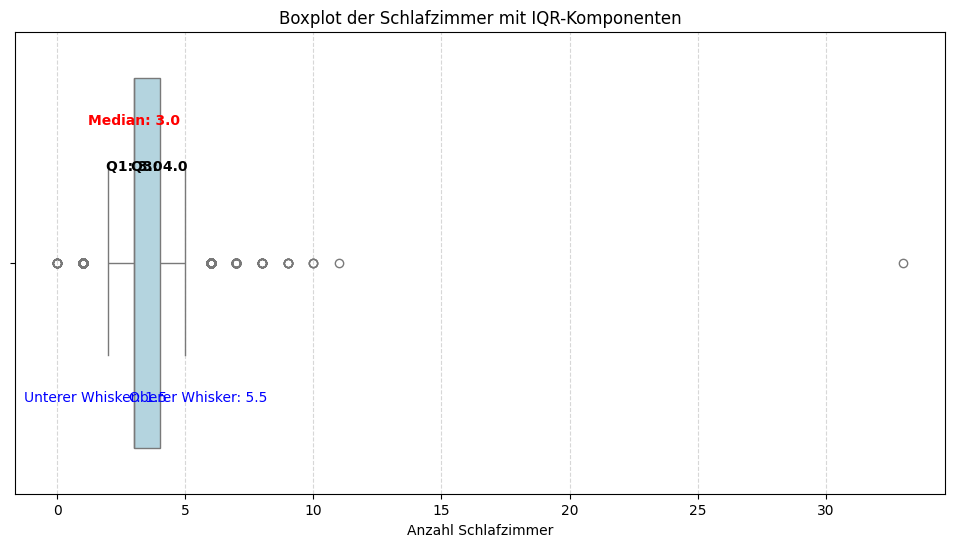

Gefundene Ausreißer: 546


In [ ]:
# IQR Berechnung der Schlafzimmer
Q1 = housing['bedrooms'].quantile(0.25)
Q3 = housing['bedrooms'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
median = housing['bedrooms'].median()

# Visualisierung
plt.figure(figsize=(12, 6))
sns.boxplot(x=housing['bedrooms'], color='lightblue', whis=1.5)

# Statistische Werte im Graphen markieren
plt.text(lower_limit, 0.3, f'Unterer Whisker: {lower_limit}', ha='center', color='blue')
plt.text(Q1, -0.2, f'Q1: {Q1}', ha='center', fontweight='bold')
plt.text(median, -0.3, f'Median: {median}', ha='center', color='red', fontweight='bold')
plt.text(Q3, -0.2, f'Q3: {Q3}', ha='center', fontweight='bold')
plt.text(upper_limit, 0.3, f'Oberer Whisker: {upper_limit}', ha='center', color='blue')

plt.title('Boxplot der Schlafzimmer mit IQR-Komponenten')
plt.xlabel('Anzahl Schlafzimmer')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

print(f"Gefundene Ausreißer: {len(housing[(housing['bedrooms'] < lower_limit) | (housing['bedrooms'] > upper_limit)])}")

In [ ]:
# Z-Score für Schlafzimmer berechnen
z_scores = np.abs(stats.zscore(housing['bedrooms']))

# Schwellenwert (Threshold) von 3 festlegen
outliers_zscore = housing[z_scores > 3]

print(f"Gefundene Ausreißer mit Z-Score: {len(outliers_zscore)}")

Gefundene Ausreißer mit Z-Score: 75


In [ ]:
#key_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
            'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']

print(f"{'Feature':25s} {'Mean':>14s} {'Std':>14s} {'#Outlier':>10s} {'% Outlier':>10s}")
print("-" * 80)

for col in key_cols:
    z = np.abs(stats.zscore(housing[col].dropna()))
    n_outliers = (z > 3).sum()
    pct = n_outliers / len(housing) * 100
    print(f"{col:25s} {housing[col].mean():14.2f} {housing[col].std():14.2f} {n_outliers:10d} {pct:9.2f}%")

Feature                             Mean            Std   #Outlier  % Outlier
--------------------------------------------------------------------------------
price                          540088.14      367127.20        406      1.88%
bedrooms                            3.37           0.93         75      0.35%
bathrooms                           2.11           0.77        187      0.87%
sqft_living                      2079.90         918.44        248      1.15%
sqft_lot                        15106.97       41420.51        347      1.61%
sqft_above                       1788.39         828.09        254      1.18%
sqft_basement                     291.51         442.58        247      1.14%
sqft_living15                    1986.55         685.39        237      1.10%
sqft_lot15                      12768.46       27304.18        363      1.68%


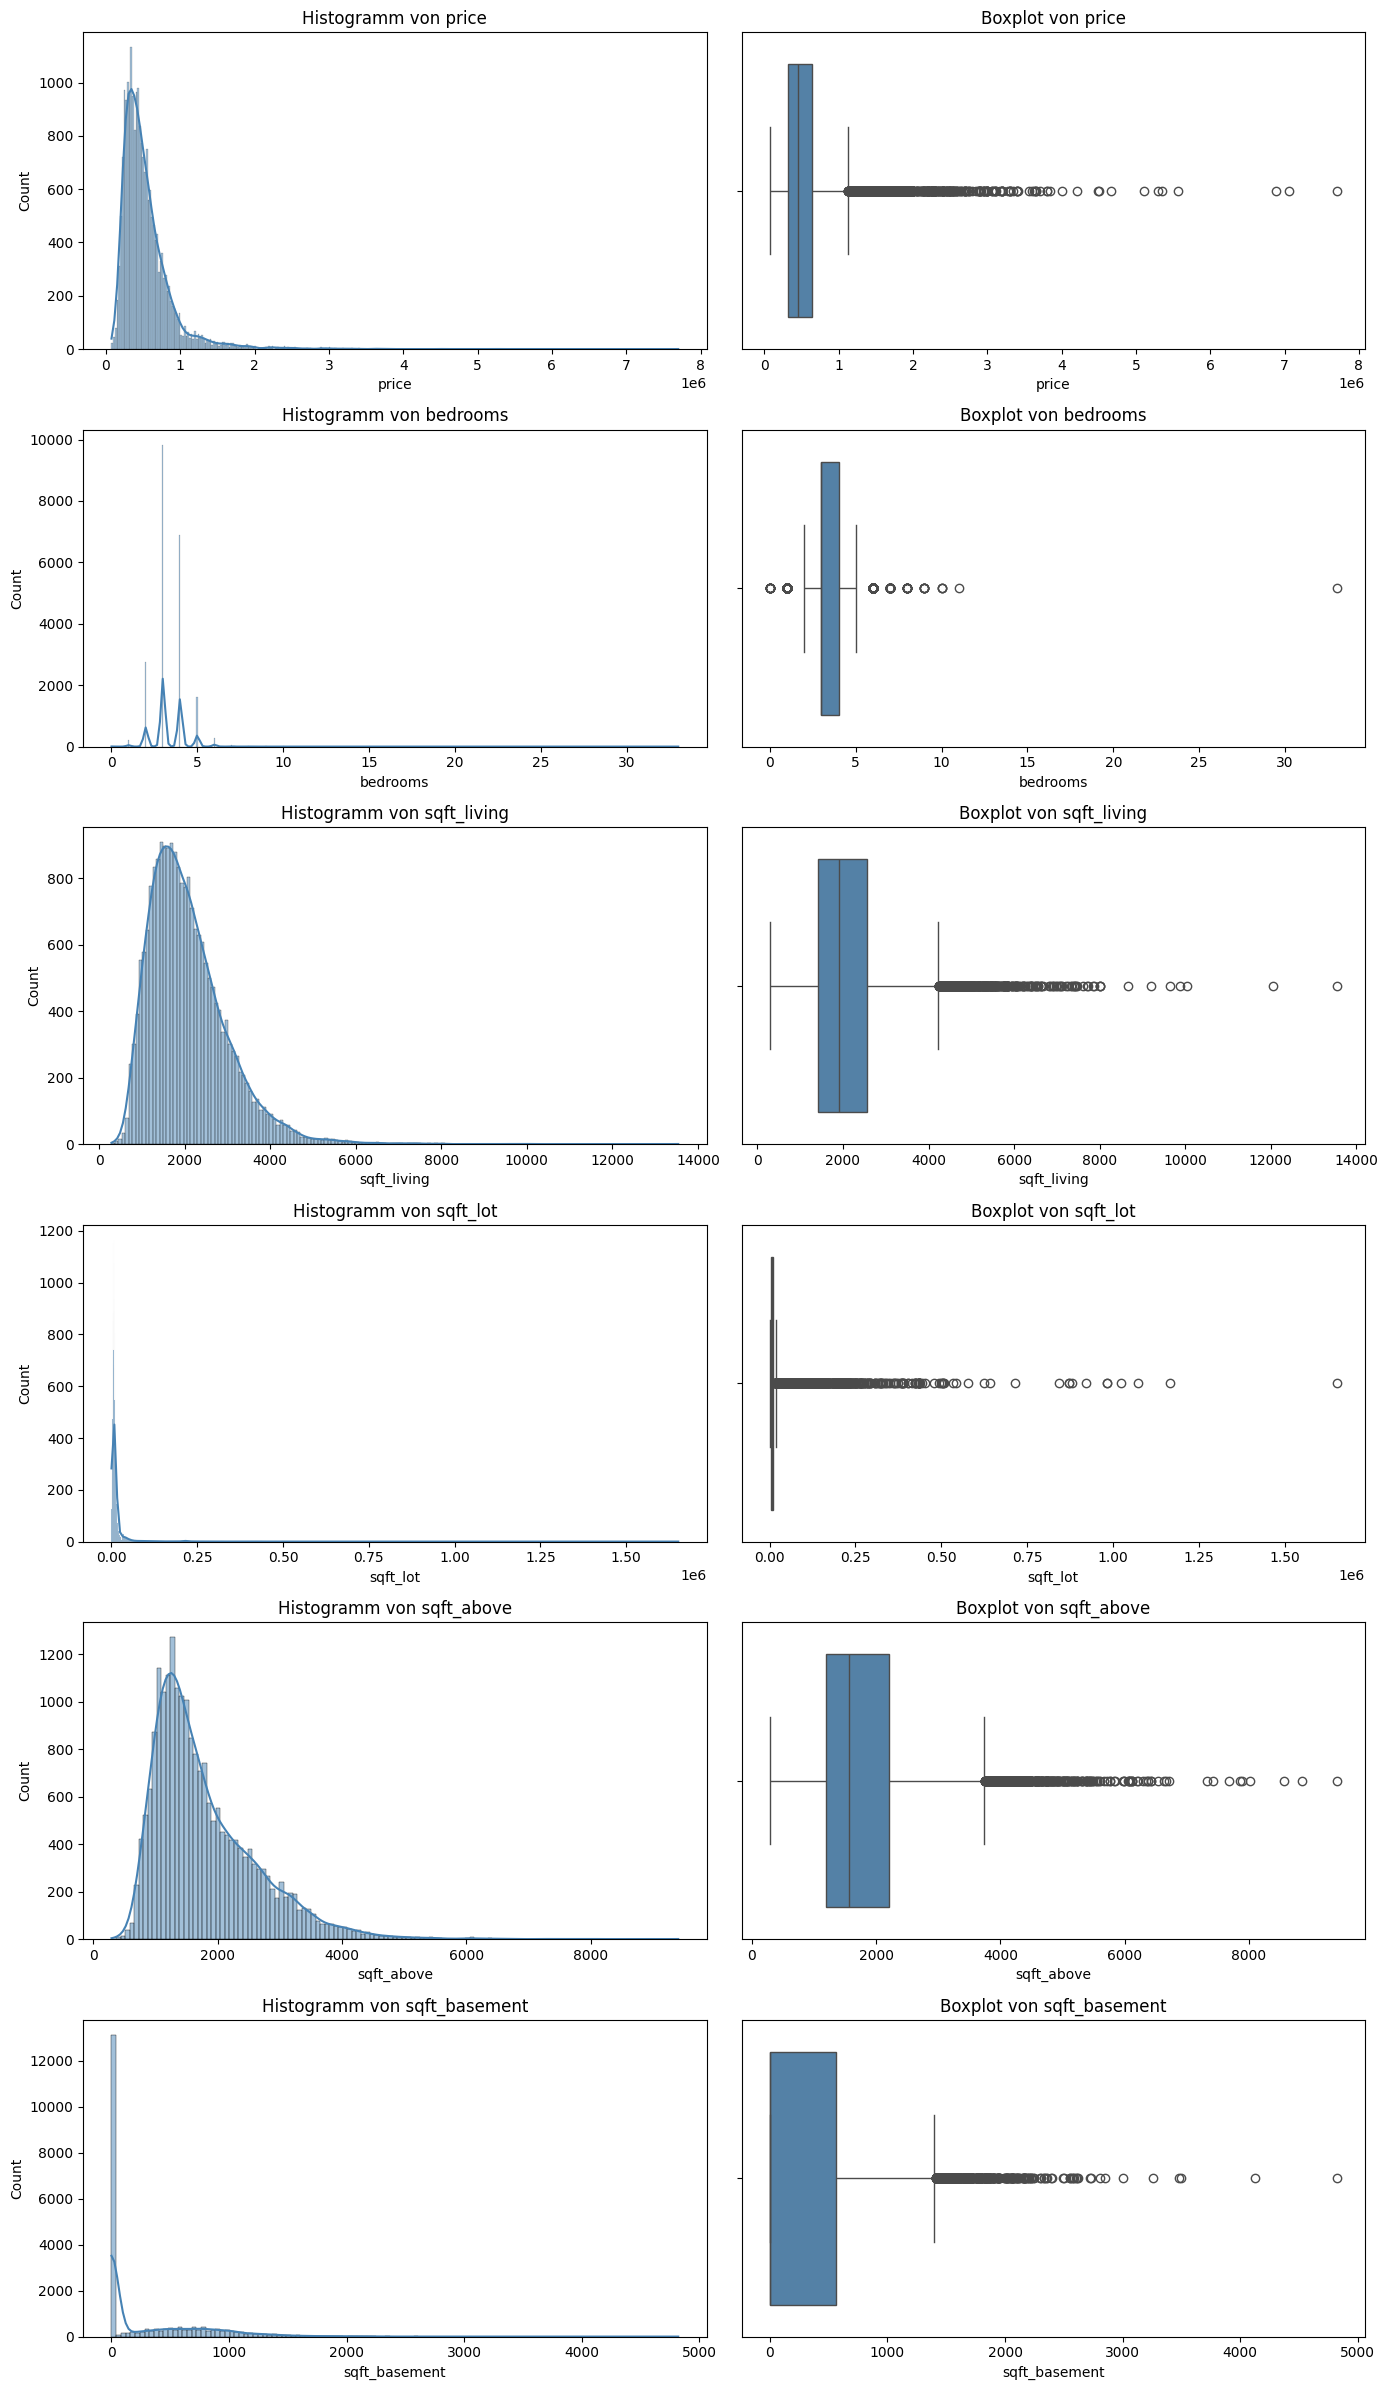

In [ ]:
plot_cols = ['price', 'bedrooms', 'sqft_living', 'sqft_lot',
             'sqft_above', 'sqft_basement']

fig, axes = plt.subplots(len(plot_cols), 2, figsize=(14, 4 * len(plot_cols)))
for i, col in enumerate(plot_cols):
    # Histogram mit KDE
    sns.histplot(housing[col], kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'Histogramm von {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')

    # Boxplot
    sns.boxplot(x=housing[col], ax=axes[i, 1], color='steelblue')
    axes[i, 1].set_title(f'Boxplot von {col}')

plt.tight_layout()
plt.show()

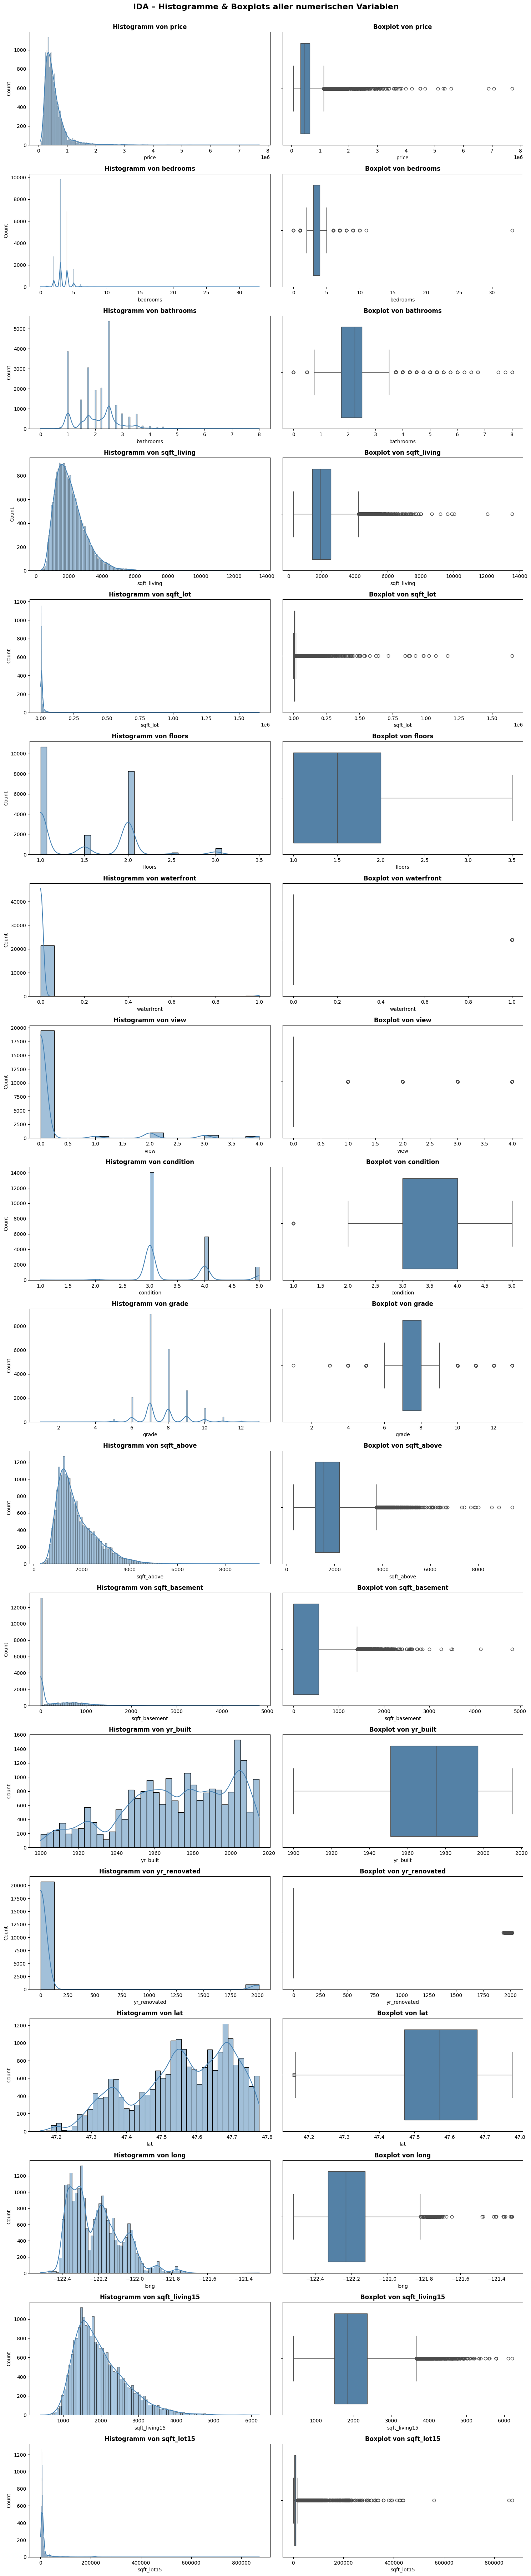

In [ ]:
# Histogramme & Boxplots für ALLE numerischen Variablen
num_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
            'floors', 'waterfront', 'view', 'condition', 'grade',
            'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
            'lat', 'long', 'sqft_living15', 'sqft_lot15']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(15, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(housing[col], kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'Histogramm von {col}', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Count')

    sns.boxplot(x=housing[col], ax=axes[i, 1], color='steelblue')
    axes[i, 1].set_title(f'Boxplot von {col}', fontsize=12, fontweight='bold')

plt.suptitle('IDA – Histogramme & Boxplots aller numerischen Variablen',
             fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

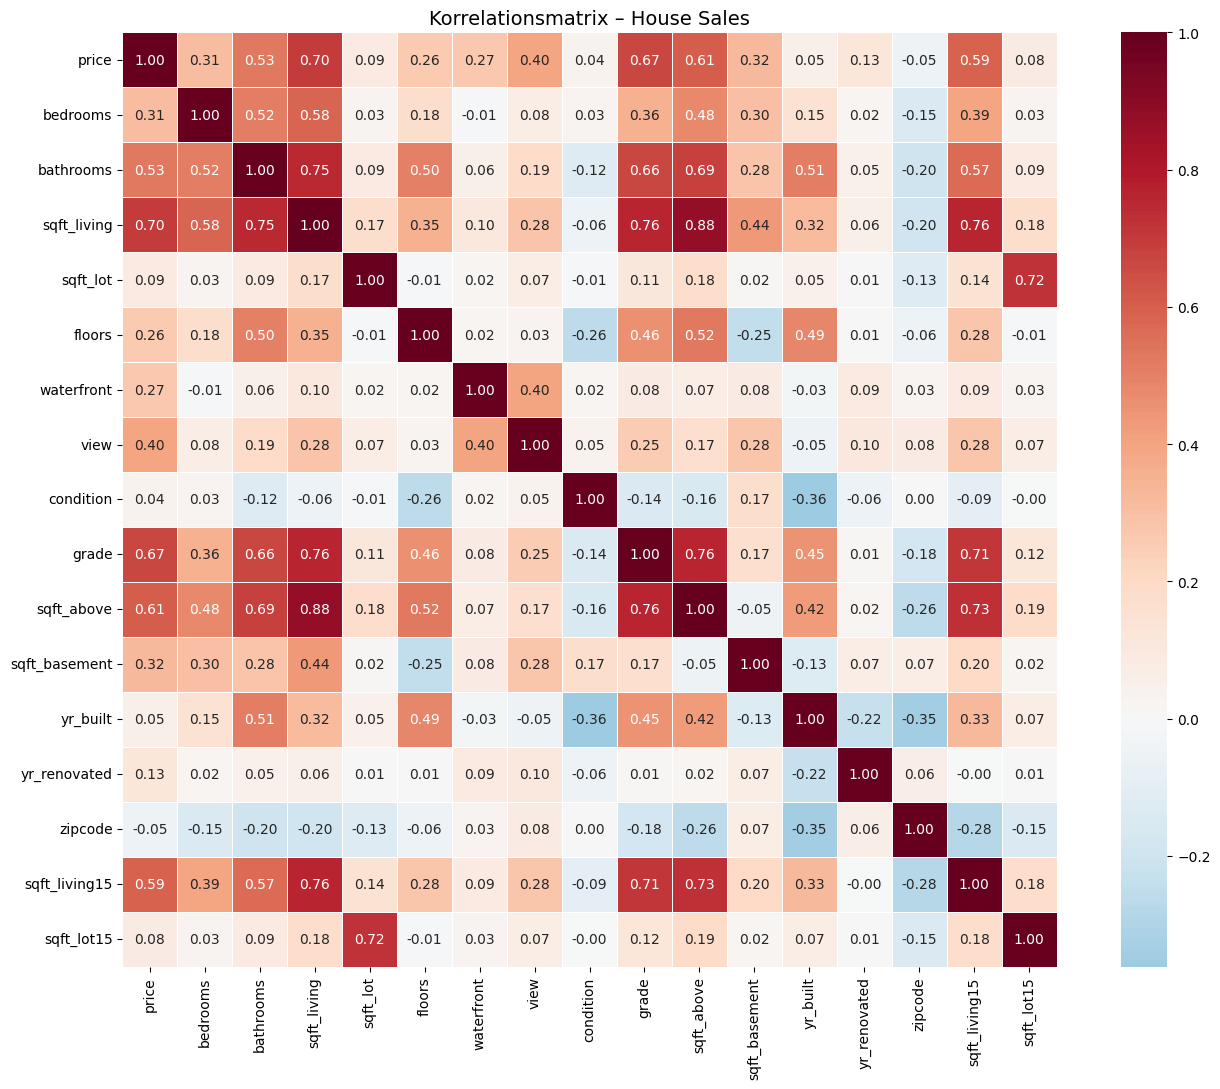

In [ ]:
# Heatmap
corr_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
             'floors', 'waterfront', 'view', 'condition', 'grade',
             'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'sqft_living15', 'sqft_lot15']
corr = housing[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Korrelationsmatrix – House Sales', fontsize=14)
plt.tight_layout()
plt.show()

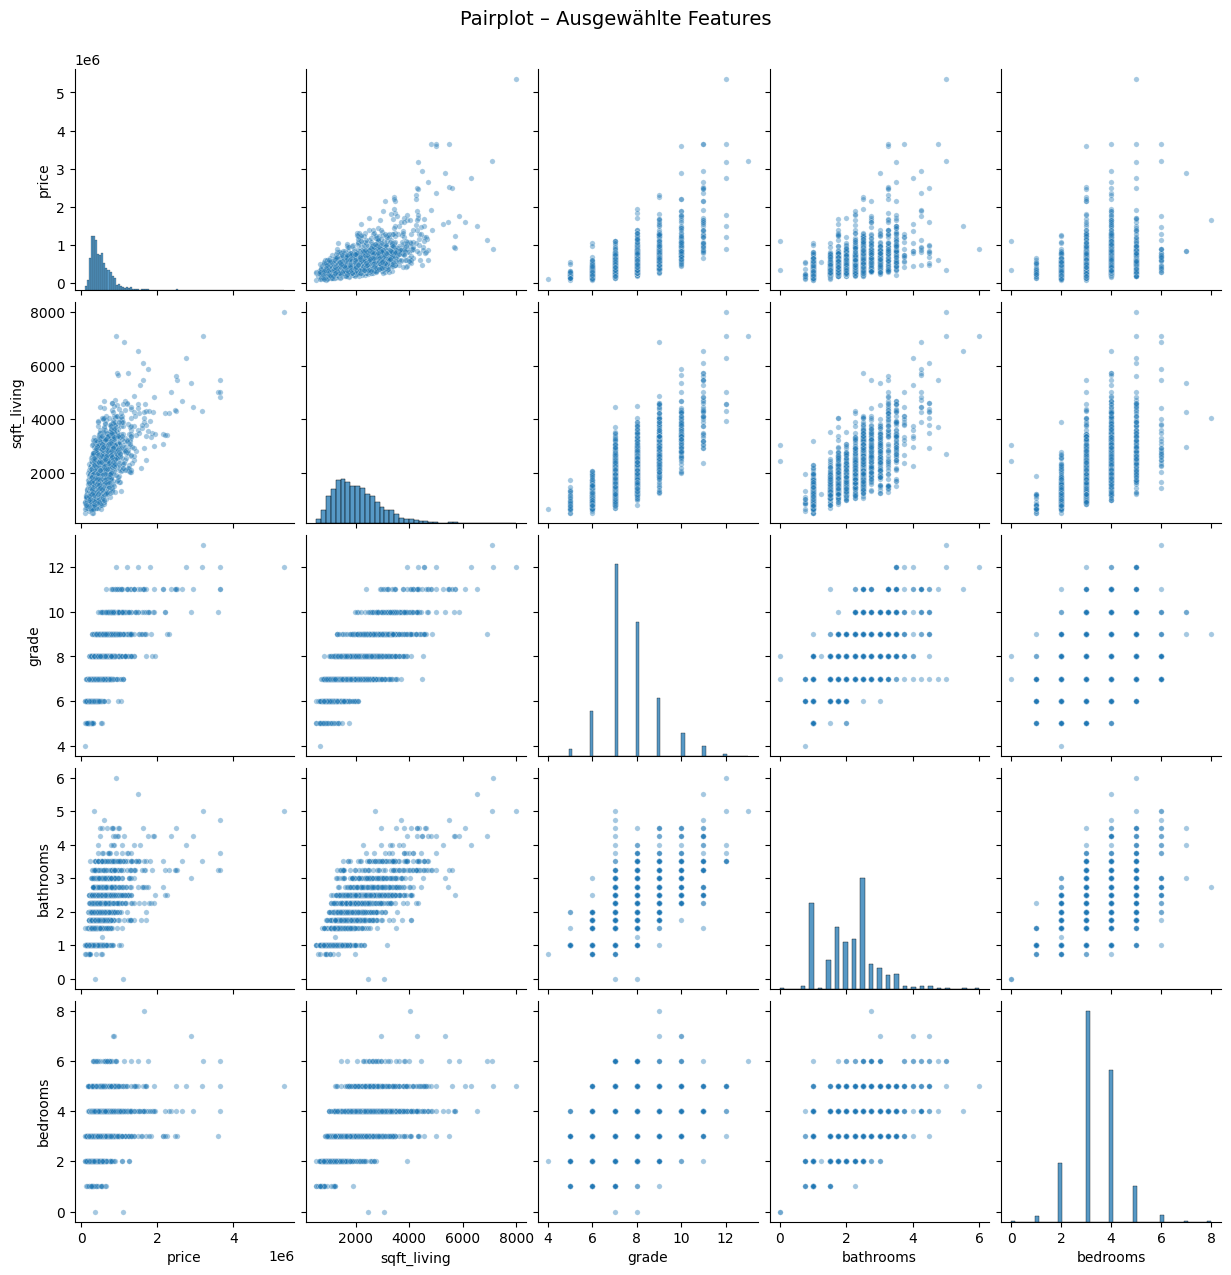

In [ ]:
pair_cols = ['price', 'sqft_living', 'grade', 'bathrooms', 'bedrooms']
g = sns.pairplot(housing[pair_cols].sample(2000, random_state=42),
                 diag_kind='hist', plot_kws={'alpha': 0.4, 's': 15})
g.fig.suptitle('Pairplot – Ausgewählte Features', y=1.02, fontsize=14)
plt.show()

In [ ]:
housing['sale_year'] = pd.to_datetime(housing['date']).dt.year

# Group by 'id' and 'sale_year' to find houses sold multiple times in the same year
multiple_sales_same_year = housing.groupby(['id', 'sale_year']).size().reset_index(name='sale_count')

# Filter for houses with more than one sale in the same year
repeated_houses = multiple_sales_same_year[multiple_sales_same_year['sale_count'] > 1]

# Get the IDs of these houses
repeated_house_ids = repeated_houses['id'].unique()

# Display all entries for these houses from the original dataset
if len(repeated_house_ids) > 0:
    print(f"Found {len(repeated_house_ids)} unique houses that were sold multiple times within the same year.")
    print("Details for these houses (including all their sales):")
    display(housing[housing['id'].isin(repeated_house_ids)].sort_values(by=['id', 'date']))
else:
    print("No houses found that were sold multiple times within the same year.")

Found 42 unique houses that were sold multiple times within the same year.
Details for these houses (including all their sales):


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year
11433,109200390,20140820T000000,245000.0,3,1.75,1480,3900,1.0,0,0,...,1480,0,1980,0,98023,47.2977,-122.367,1830,6956,2014
11434,109200390,20141020T000000,250000.0,3,1.75,1480,3900,1.0,0,0,...,1480,0,1980,0,98023,47.2977,-122.367,1830,6956,2014
12417,123039336,20140611T000000,148000.0,1,1.00,620,8261,1.0,0,0,...,620,0,1939,0,98106,47.5138,-122.364,1180,8244,2014
12418,123039336,20141208T000000,244900.0,1,1.00,620,8261,1.0,0,0,...,620,0,1939,0,98106,47.5138,-122.364,1180,8244,2014
3785,723049156,20140523T000000,149000.0,3,1.00,1700,8645,1.0,0,0,...,1700,0,1955,0,98146,47.4899,-122.337,1500,7980,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6790,8651510380,20141216T000000,539000.0,3,2.00,2070,9195,1.0,0,0,...,1220,850,1982,0,98074,47.6491,-122.061,2080,9551,2014
11586,8807810890,20140827T000000,259875.0,3,1.00,1250,21303,1.0,0,0,...,1250,0,1970,0,98053,47.6625,-122.059,1250,17920,2014
11587,8807810890,20141105T000000,385000.0,3,1.00,1250,21303,1.0,0,0,...,1250,0,1970,0,98053,47.6625,-122.059,1250,17920,2014
10226,8945100320,20140506T000000,136500.0,3,1.50,1420,8580,1.0,0,0,...,1420,0,1962,0,98023,47.3076,-122.362,1200,8580,2014


In [ ]:
# Verdächtiger Datensatz: bedrooms = 33
outlier_bed = housing[housing['bedrooms'] == 33]
print("--- bedrooms = 33 ---")
print(outlier_bed[['id','price','bedrooms','bathrooms','sqft_living','sqft_lot']])
print(f"\n→ 33 Schlafzimmer bei nur {outlier_bed['sqft_living'].values[0]} sqft")
print(f"  und {outlier_bed['bathrooms'].values[0]} Bädern → fast sicher Tippfehler (vermutlich 3)")

# Häuser mit 0 Schlafzimmern
print(f"\n--- bedrooms = 0: {(housing['bedrooms']==0).sum()} Häuser ---")
print(f"  Preisrange: ${housing[housing['bedrooms']==0]['price'].min():,.0f} – ${housing[housing['bedrooms']==0]['price'].max():,.0f}")

# Häuser mit 0 Badezimmern
print(f"\n--- bathrooms = 0: {(housing['bathrooms']==0).sum()} Häuser ---")

# yr_renovated = 0
print(f"\n--- yr_renovated = 0: {(housing['yr_renovated']==0).sum()} von {len(housing)} ({(housing['yr_renovated']==0).sum()/len(housing)*100:.1f}%) ---")
print("  → 0 bedeutet 'nie renoviert', nicht fehlend – aber ambig codiert")

# Konsistenz sqft
consistent = (housing['sqft_living'] == housing['sqft_above'] + housing['sqft_basement']).all()
print(f"\n--- sqft_living = sqft_above + sqft_basement: {'✓ Konsistent' if consistent else '✗ Inkonsistent'} ---")

# Duplikate
print(f"\n--- Doppelte IDs: {housing['id'].duplicated().sum()} (Wiederverkäufe) ---")

# Preisextreme
print(f"\n--- Preisextreme ---")
print(f"  Min: ${housing['price'].min():,.0f}, Max: ${housing['price'].max():,.0f}, Median: ${housing['price'].median():,.0f}")
print(f"  Häuser > $5M: {(housing['price'] > 5_000_000).sum()}")